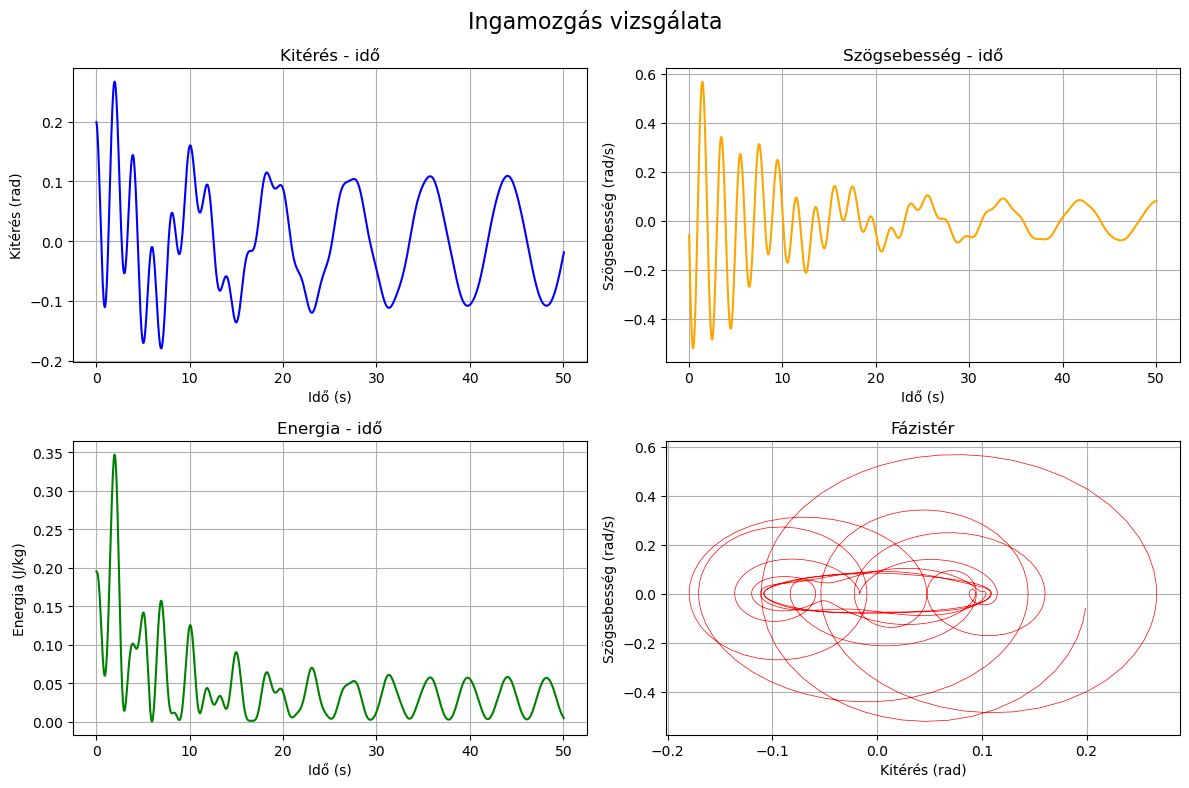

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("datas/pendulum.data")
t = data[:, 0]
theta = data[:, 1]
omega = data[:, 2]
energy = data[:, 3]

fig, axs = plt.subplots(2, 2, figsize = (12, 8))
fig.suptitle("Ingamozgás vizsgálata", fontsize = 16)

# 1. kitérés - idő
axs[0, 0].plot(t, theta, color = "blue")
axs[0, 0].set_title("Kitérés - idő")
axs[0, 0].set_xlabel("Idő (s)")
axs[0, 0].set_ylabel("Kitérés (rad)")
axs[0, 0].grid(True)

# 2. sebesség - idő
axs[0, 1].plot(t, omega, color = "orange")
axs[0, 1].set_title("Szögsebesség - idő")
axs[0, 1].set_xlabel("Idő (s)")
axs[0, 1].set_ylabel("Szögsebesség (rad/s)")
axs[0, 1].grid(True)

# 3. Energia - idő
axs[1, 0].plot(t, energy, color = "green")
axs[1, 0].set_title("Energia - idő")
axs[1, 0].set_xlabel("Idő (s)")
axs[1, 0].set_ylabel("Energia (J/kg)")
axs[1, 0].grid(True)

energy_range = np.max(energy) - np.min(energy)
if energy_range < 1e-3:
    mean_energy = np.mean(energy)
    axs[1, 0].set_ylim(mean_energy - 0.01, mean_energy + 0.01)

# 4. kitérés - sebesség
axs[1, 1].plot(theta, omega, color = "red", linewidth = 0.5)
axs[1, 1].set_title("Fázistér")
axs[1, 1].set_xlabel("Kitérés (rad)")
axs[1, 1].set_ylabel("Szögsebesség (rad/s)")
axs[1, 1].grid(True)

plt.tight_layout()
plt.savefig("complex_aRK4.png")
plt.show()

1. ábra:
l, 1, 0, 0, 0, 0.1, 0, 50

2. ábra:
n, 1, 0, 0, 0, 1, 0, 50

3. ábra:
n, 1, 0.25, 0, 0, 1, 0, 50

4. ábra:
n, 1, 0.25, 0.75, 1, 0.2, 0, 100

-----------------------------------------

1.
l, 1, 0, 0, 0, 0.1, 0, 50

2.
n, 1, 0.25, 0.75, 1, 0.2, 0, 50

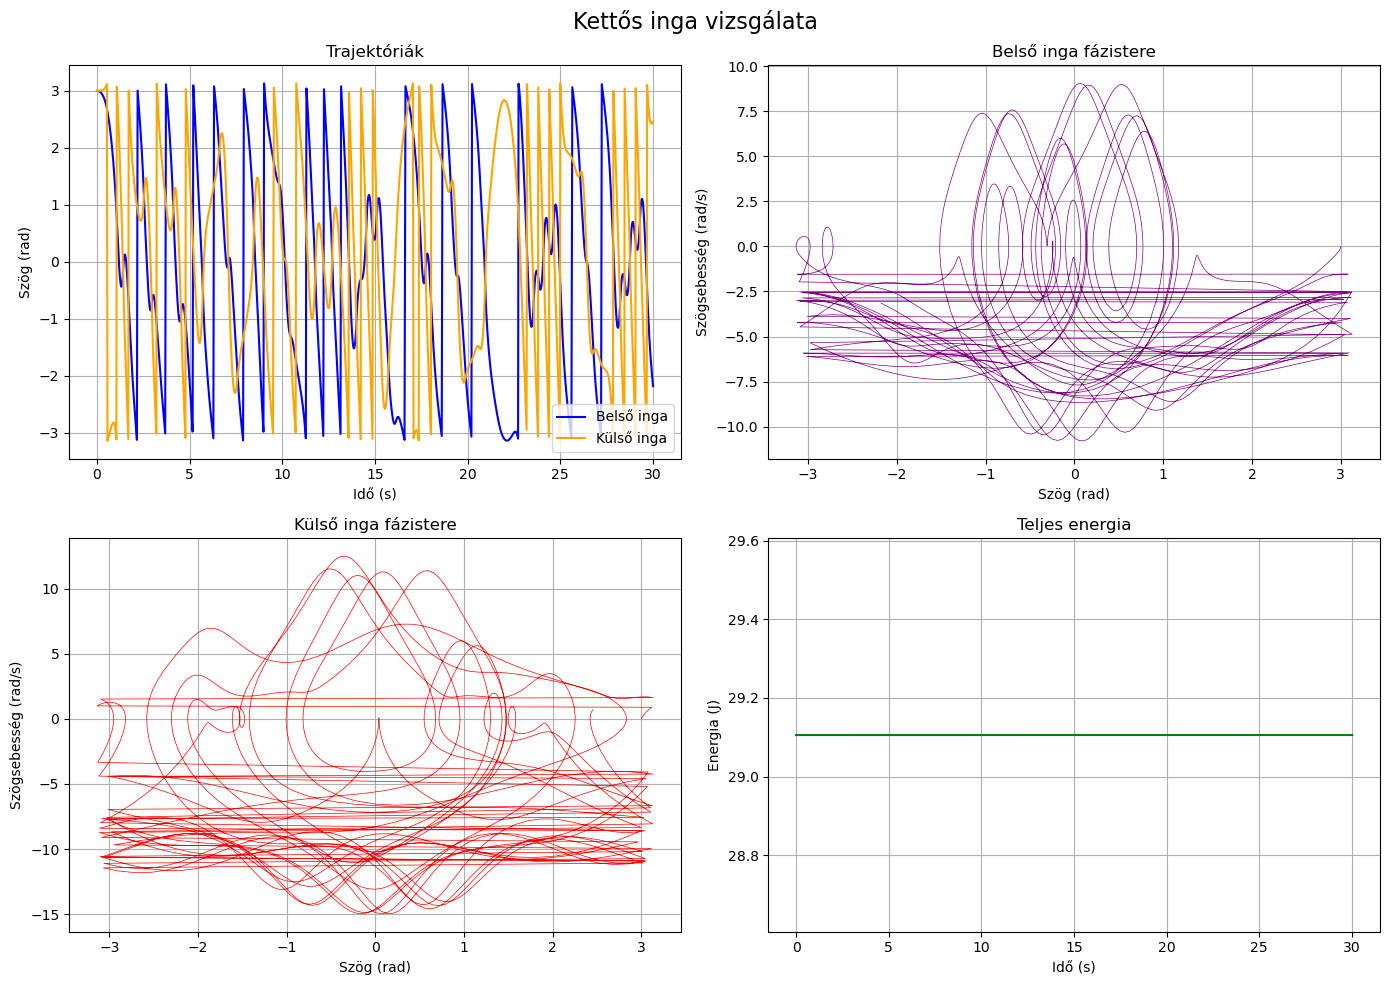

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("datas/double_pendulum.data")
t = data[:, 0]
th1 = data[:, 1]
th2 = data[:, 2]
w1 = data[:, 3]
w2 = data[:, 4]
energy = data[:, 5]

th1_wrapped = (th1 + np.pi) % (2 * np.pi) - np.pi
th2_wrapped = (th2 + np.pi) % (2 * np.pi) - np.pi

th1_plot = th1_wrapped.copy()
th2_plot = th2_wrapped.copy()

jump_idx1 = np.where(np.abs(np.diff(th1_wrapped)) > np.pi)[0]
jump_idx2 = np.where(np.abs(np.diff(th2_wrapped)) > np.pi)[0]

th1_plot[jump_idx1] = np.nan
th2_plot[jump_idx2] = np.nan

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Kettős inga vizsgálata", fontsize=16)

axs[0, 0].plot(t, th1_plot, label = "Belső inga", color = "blue", markersize = 1)
axs[0, 0].plot(t, th2_plot, label = "Külső inga", color = "orange", markersize = 1)
axs[0, 0].set_title("Trajektóriák")
axs[0, 0].set_xlabel("Idő (s)")
axs[0, 0].set_ylabel("Szög (rad)")
axs[0, 0].grid(True)
axs[0, 0].legend()

axs[0, 1].plot(th1_plot, w1, color = "purple", linewidth = 0.5)
axs[0, 1].set_title("Belső inga fázistere")
axs[0, 1].set_xlabel("Szög (rad)")
axs[0, 1].set_ylabel("Szögsebesség (rad/s)")
axs[0, 1].grid(True)

axs[1, 0].plot(th2_plot, w2, color = "red", linewidth = 0.5)
axs[1, 0].set_title("Külső inga fázistere")
axs[1, 0].set_xlabel("Szög (rad)")
axs[1, 0].set_ylabel("Szögsebesség (rad/s)")
axs[1, 0].grid(True)

axs[1, 1].plot(t, energy, color = "green")
axs[1, 1].set_title("Teljes energia")
axs[1, 1].set_xlabel("Idő (s)")
axs[1, 1].set_ylabel("Energia (J)")
axs[1, 1].grid(True)
mean_energy = np.mean(energy)
axs[1, 1].set_ylim(mean_energy - 0.5, mean_energy + 0.5)

plt.tight_layout()
plt.savefig("double_3.png")
plt.show()

1. ábra:
0.1, 0.2, 0, 0, 50

2. ábra:
1.57, 1.57, 0, 0, 50

3. ábra:
3, 3, 0, 0, 30